# Exploratory Data Analysis



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load the Datasets


In [2]:
# main traffic + user needs data
eda_df = pd.read_csv('Data/EDA_data-TITLES.csv')

# the big parsely export
posts_df = pd.read_csv('Data/posts-export-by-page-views-Feb-01-2025-Mar-05-2026-Masthead-Maine.csv')

# articles that already have user needs labels
tagged_df = pd.read_csv('Data/ML_tagged_data-TITLES.csv')

# articles without labels — these are the ones we need to classify later
untagged_df = pd.read_csv('Data/ML_untagged_data-TITLES.csv')

print('EDA data:', eda_df.shape)
print('Posts export:', posts_df.shape)
print('Tagged:', tagged_df.shape)
print('Untagged:', untagged_df.shape)

EDA data: (9117, 14)
Posts export: (10000, 47)
Tagged: (3928, 3)
Untagged: (5189, 3)


In [3]:
print('--- EDA Data (first 5 rows) ---')
eda_df.head()

--- EDA Data (first 5 rows) ---


,Apikey,URL,Title,Publish date,Authors,Section,User_Needs,Views,Avg. views,Engaged minutes,Avg. minutes,Desktop views,Mobile views,Tablet views
0,"pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/09/gray-inv...,Gray investigated for buying $1.25M fire truck...,2026-01-09 08:55,Rory Sweeting,News,update-me,109875,1.084,31960.0,0.315,3910.0,104307.0,1658.0
1,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/03/06/social-...,Social Security now requires Maine parents to ...,2025-03-06 17:14,Joe Lawlor,News,none,98329,1.109,64495.0,0.727,9783.0,86241.0,2305.0
2,"centralmaine.com, pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/28/ice-agen...,"ICE agents shatter window, leave 1-month-old b...",2026-01-28 17:43,"Dylan Tusinski,Salomé Cloteaux",News,give-me-perspective,76168,1.145,84939.0,1.277,12634.0,61819.0,1715.0
3,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/02/05/maine-m...,Maine Mall shooting: Police search for suspect...,2025-02-05 16:21,"Daniel Kool,Morgan Womack",News,none,73901,1.341,38065.0,0.691,14806.0,58483.0,612.0
4,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/09/01/bob-dyl...,Bob Dylan and Willie Nelson headline Outlaw Mu...,2025-09-01 04:00,Aimsel Ponti,Life & Culture,none,64763,1.155,23763.0,0.424,2635.0,59514.0,2614.0


In [4]:
print('--- Posts Export (first 5 rows) ---')
posts_df.head()

--- Posts Export (first 5 rows) ---


,Apikey,URL,Title,Publish date,Authors,Section,Tags,Sort (Views),Visitors,Views,...,Channel vis.,Website views,AMP views,Fb instant views,Post id,Views source,Views syndicated,Views by Site,High-Level Smart Tags,Low-Level Smart Tags
0,pressherald.com,https://www.pressherald.com,The Portland Press Herald,NaN,Staff,Uncategorized,NaN,13604769,1188026,13604769,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,centralmaine.com,https://www.centralmaine.com,Kennebec Journal and Morning Sentinel,NaN,Staff,Uncategorized,NaN,4571551,453052,4571551,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Law, Gov’t & Politics,Legal Issues",NaN
2,pressherald.com,http://www.pressherald.com/obituaries/,Obituaries,NaN,Staff,Uncategorized,NaN,3465736,410059,3465736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sunjournal.com,https://www.sunjournal.com,Lewiston Sun Journal,NaN,Staff,Uncategorized,NaN,3436858,367361,3436858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,centralmaine.com,https://www.centralmaine.com/obituaries/,Obituaries,NaN,Staff,Uncategorized,NaN,3284383,275492,3284383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print('--- Tagged Data ---')
print(tagged_df.shape)
tagged_df.head()

--- Tagged Data ---
(3928, 3)


,URL,Title,User_Needs
0,http://www.pressherald.com/2026/01/09/gray-inv...,Gray investigated for buying $1.25M fire truck...,update-me
1,http://www.pressherald.com/2026/01/28/ice-agen...,"ICE agents shatter window, leave 1-month-old b...",give-me-perspective
2,http://www.pressherald.com/2025/10/21/graham-p...,Graham Platner says he will remove a Nazi-link...,educate-me
3,http://www.pressherald.com/2025/09/24/trump-ad...,Trump administration cancels USM college progr...,update-me
4,http://www.pressherald.com/2026/01/23/ice-watc...,ICE watchers in Maine say they were threatened...,update-me


In [6]:
print('--- Untagged Data ---')
print(untagged_df.shape)
untagged_df.head()

--- Untagged Data ---
(5189, 3)


,URL,Title,User_Needs
0,https://www.pressherald.com/2025/03/06/social-...,Social Security now requires Maine parents to ...,none
1,https://www.pressherald.com/2025/02/05/maine-m...,Maine Mall shooting: Police search for suspect...,none
2,https://www.pressherald.com/2025/09/01/bob-dyl...,Bob Dylan and Willie Nelson headline Outlaw Mu...,none
3,https://www.pressherald.com/2025/05/06/maine-h...,Maine housing advocates warn of coming ‘tsunam...,none
4,http://www.pressherald.com/2025/11/04/maine-st...,Follow live: Maine statewide and town-by-town ...,none


## Data Types and Missing Values


In [7]:
print('=== EDA Data Info ===')
print(eda_df.dtypes)
print()
print('Missing values:')
print(eda_df.isnull().sum())
print()
print(f'Total rows: {len(eda_df)}, Total missing cells: {eda_df.isnull().sum().sum()}')

=== EDA Data Info ===
Apikey                 str
URL                    str
Title                  str
Publish date           str
Authors                str
Section                str
User_Needs             str
Views                int64
Avg. views         float64
Engaged minutes    float64
Avg. minutes       float64
Desktop views      float64
Mobile views       float64
Tablet views       float64
dtype: object

Missing values:
Apikey             0
URL                0
Title              0
Publish date       0
Authors            0
Section            0
User_Needs         0
Views              0
Avg. views         0
Engaged minutes    0
Avg. minutes       0
Desktop views      0
Mobile views       0
Tablet views       0
dtype: int64

Total rows: 9117, Total missing cells: 0


In [8]:
print('=== Posts Export Info ===')
print(posts_df.dtypes)
print()
print('Missing values:')
print(posts_df.isnull().sum())
print()
print(f'Total rows: {len(posts_df)}, Total missing cells: {posts_df.isnull().sum().sum()}')

=== Posts Export Info ===
Apikey                        str
URL                           str
Title                         str
Publish date                  str
Authors                       str
Section                       str
Tags                          str
Sort (Views)                int64
Visitors                    int64
Views                       int64
Avg. views                float64
Engaged minutes           float64
Avg. minutes              float64
New vis.                    int64
Views new vis.              int64
Avg. views new vis.       float64
Minutes New Vis.          float64
Avg. minutes new vis.     float64
Returning vis.            float64
Views ret. vis.           float64
Avg. views ret. vis.      float64
Minutes Ret. Vis.         float64
Avg. minutes ret. vis.    float64
Desktop views             float64
Mobile views              float64
Tablet views              float64
Search refs               float64
Internal refs             float64
Other refs            

In [9]:
print('=== Tagged Data ===')
print(tagged_df.dtypes)
print()
print('Missing values:')
print(tagged_df.isnull().sum())
print()
print(f'Total rows: {len(tagged_df)}')

=== Tagged Data ===
URL           str
Title         str
User_Needs    str
dtype: object

Missing values:
URL           0
Title         0
User_Needs    0
dtype: int64

Total rows: 3928


In [10]:
print('=== Untagged Data ===')
print(untagged_df.dtypes)
print()
print('Missing values:')
print(untagged_df.isnull().sum())
print()
print(f'Total rows: {len(untagged_df)}')

=== Untagged Data ===
URL           str
Title         str
User_Needs    str
dtype: object

Missing values:
URL           0
Title         0
User_Needs    0
dtype: int64

Total rows: 5189


## Description

In [11]:
eda_df.describe()

,Views,Avg. views,Engaged minutes,Avg. minutes,Desktop views,Mobile views,Tablet views
count,9117.000000,9117.000000,9117.000000,9117.000000,9117.000000,9117.000000,9117.000000
mean,3207.525941,1.249237,2093.950093,0.784424,1082.512998,2061.039158,63.973346
std,4675.475642,2.015034,3388.032485,0.362827,1173.264999,3668.032484,110.303801
min,741.000000,0.992000,14.000000,0.009000,4.000000,25.000000,0.000000
25%,1109.000000,1.147000,624.000000,0.526000,458.000000,613.000000,18.000000
50%,1802.000000,1.201000,1104.000000,0.722000,715.000000,1026.000000,33.000000
75%,3434.000000,1.267000,2240.000000,0.982000,1262.000000,2038.000000,67.000000
max,109875.000000,193.000000,84939.000000,11.200000,19047.000000,104307.000000,2614.000000


In [12]:
# same for the posts export
posts_df.describe()

,Sort (Views),Visitors,Views,Avg. views,Engaged minutes,Avg. minutes,New vis.,Views new vis.,Avg. views new vis.,Minutes New Vis.,...,Pi refs,Social interactions,Fb interactions,Pi interactions,Channel vis.,Website views,AMP views,Fb instant views,Views source,Views syndicated
count,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.000000,9999.000000,...,34.000000,7657.000000,7652.000000,51.000000,27.000000,9117.000000,0.0,0.0,5163.000000,6408.000000
mean,7.706867e+03,3.211805e+03,7.706867e+03,1.344130,3.757012e+03,0.787025,1537.820700,2.037449e+03,1.163249,881.705131,...,10.294118,189.452396,189.567041,1.411765,-3.518519,3207.525502,NaN,NaN,2859.044160,2259.963951
std,1.591038e+05,1.566168e+04,1.591038e+05,2.065319,7.299397e+04,0.527304,10843.676082,2.057905e+04,0.178538,9264.475296,...,29.241450,483.707864,483.836901,0.962839,3.555823,4675.475831,NaN,NaN,4350.852959,3815.069873
min,7.410000e+02,5.000000e+00,7.410000e+02,0.976000,1.100000e+00,0.001000,4.000000,4.000000e+00,0.972000,0.800000,...,1.000000,1.000000,1.000000,1.000000,-17.000000,741.000000,NaN,NaN,26.000000,1.000000
25%,1.113000e+03,8.960000e+02,1.113000e+03,1.152000,5.910000e+02,0.507750,321.000000,3.910000e+02,1.088000,142.000000,...,1.000000,22.000000,22.000000,1.000000,-4.000000,1109.000000,NaN,NaN,963.000000,724.750000
50%,1.833500e+03,1.480000e+03,1.833500e+03,1.209000,1.075000e+03,0.706500,552.000000,6.630000e+02,1.133000,262.000000,...,1.000000,61.000000,61.000000,1.000000,-2.000000,1802.000000,NaN,NaN,1579.000000,1221.000000
75%,3.553000e+03,2.882000e+03,3.553000e+03,1.290000,2.234500e+03,0.970000,1119.000000,1.325000e+03,1.196000,572.000000,...,2.000000,163.000000,164.000000,1.000000,-2.000000,3434.000000,NaN,NaN,3022.000000,2447.750000
max,1.360477e+07,1.188026e+06,1.360477e+07,193.000000,6.493592e+06,17.895000,833153.000000,1.673029e+06,10.185000,792400.000000,...,143.000000,12086.000000,12086.000000,6.000000,-1.000000,109875.000000,NaN,NaN,90820.000000,109875.000000


## User Needs Distribution


In [13]:
# from the EDA dataset
print('User Needs in EDA data:')
print(eda_df['User_Needs'].value_counts())
print()
print('As percentages:')
print(round(eda_df['User_Needs'].value_counts(normalize=True) * 100, 2))

User Needs in EDA data:
User_Needs
none                   5184
update-me              1956
give-me-perspective     738
educate-me              594
connect-me              312
inspire-me              223
help-me                 105
other-not-news            5
Name: count, dtype: int64

As percentages:
User_Needs
none                   56.86
update-me              21.45
give-me-perspective     8.09
educate-me              6.52
connect-me              3.42
inspire-me              2.45
help-me                 1.15
other-not-news          0.05
Name: proportion, dtype: float64


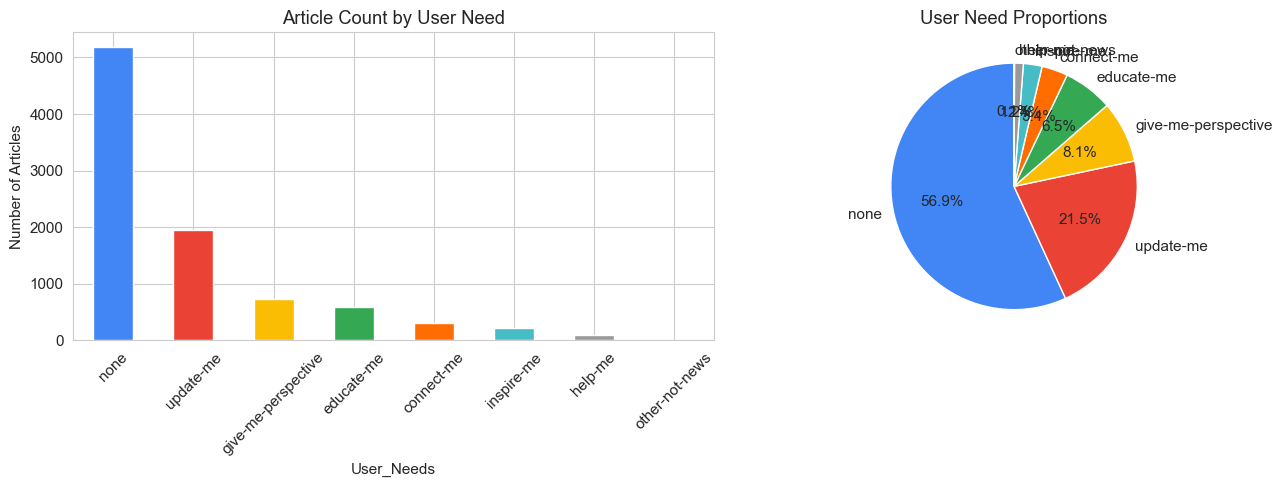

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

need_counts = eda_df['User_Needs'].value_counts()
colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853', '#FF6D01', '#46BDC6']
if len(need_counts) > len(colors):
    colors = colors + ['#999999'] * (len(need_counts) - len(colors))

need_counts.plot(kind='bar', ax=axes[0], color=colors[:len(need_counts)])
axes[0].set_title('Article Count by User Need')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=45)

need_counts.plot(kind='pie', ax=axes[1], colors=colors[:len(need_counts)],
                 autopct='%1.1f%%', startangle=90)
axes[1].set_title('User Need Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [15]:
# now check the tagged dataset
print('User Needs in Tagged ML data:')
print(tagged_df['User_Needs'].value_counts())
print()
print('As percentages:')
print(round(tagged_df['User_Needs'].value_counts(normalize=True) * 100, 2))

User Needs in Tagged ML data:
User_Needs
update-me              1956
give-me-perspective     738
educate-me              594
connect-me              312
inspire-me              223
help-me                 105
Name: count, dtype: int64

As percentages:
User_Needs
update-me              49.80
give-me-perspective    18.79
educate-me             15.12
connect-me              7.94
inspire-me              5.68
help-me                 2.67
Name: proportion, dtype: float64


In [16]:
# check whats in the untagged set
print('User Needs in Untagged ML data:')
print(untagged_df['User_Needs'].value_counts())

User Needs in Untagged ML data:
User_Needs
none              5184
other-not-news       5
Name: count, dtype: int64


## Views Distribution


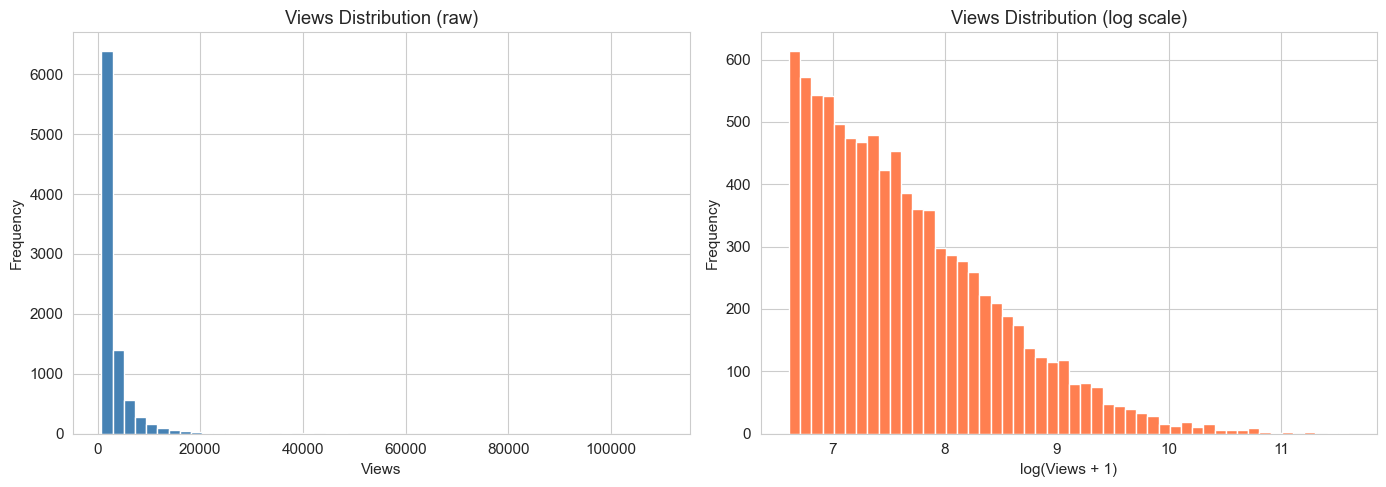

Median views: 1802.0
Mean views: 3207.53
Max views: 109875
Skewness: 7.1


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution — probably super skewed
eda_df['Views'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Views Distribution (raw)')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

# log scale to see the shape better
eda_df['Views'].apply(lambda x: np.log1p(x)).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Views Distribution (log scale)')
axes[1].set_xlabel('log(Views + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Median views: {eda_df['Views'].median()}")
print(f"Mean views: {round(eda_df['Views'].mean(), 2)}")
print(f"Max views: {eda_df['Views'].max()}")
print(f"Skewness: {round(eda_df['Views'].skew(), 2)}")

##  Average Views by User Need



In [18]:
need_perf = eda_df.groupby('User_Needs').agg(
    total_views=('Views', 'sum'),
    avg_views=('Views', 'mean'),
    median_views=('Views', 'median'),
    article_count=('Views', 'count'),
    avg_engaged_min=('Engaged minutes', 'mean')
).round(2)

need_perf = need_perf.sort_values('avg_views', ascending=False)
print(need_perf)
print()

                     total_views  avg_views  median_views  article_count  \
User_Needs                                                                 
update-me                6595865    3372.12        1982.5           1956   
educate-me               1938732    3263.86        1856.5            594   
none                    16886930    3257.51        1800.5           5184   
help-me                   309789    2950.37        1782.0            105   
give-me-perspective      2117505    2869.25        1486.0            738   
connect-me                860248    2757.21        1756.0            312   
inspire-me                526338    2360.26        1549.0            223   
other-not-news              7607    1521.40        1052.0              5   

                     avg_engaged_min  
User_Needs                            
update-me                    1984.10  
educate-me                   2237.65  
none                         2115.51  
help-me                      1878.41  
give-

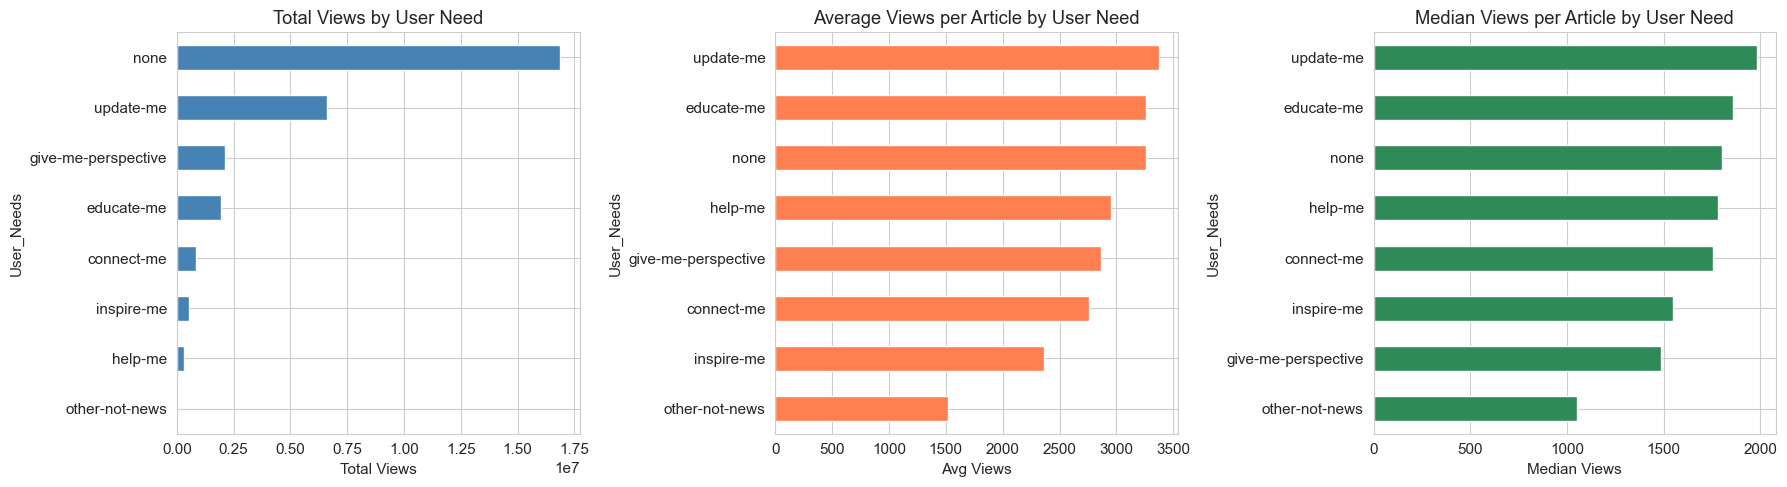

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

need_perf_sorted = need_perf.sort_values('total_views', ascending=True)
need_perf_sorted['total_views'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Views by User Need')
axes[0].set_xlabel('Total Views')

need_perf_sorted2 = need_perf.sort_values('avg_views', ascending=True)
need_perf_sorted2['avg_views'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average Views per Article by User Need')
axes[1].set_xlabel('Avg Views')

need_perf_sorted3 = need_perf.sort_values('median_views', ascending=True)
need_perf_sorted3['median_views'].plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Median Views per Article by User Need')
axes[2].set_xlabel('Median Views')

plt.tight_layout()
plt.show()

## Engagement by User Need


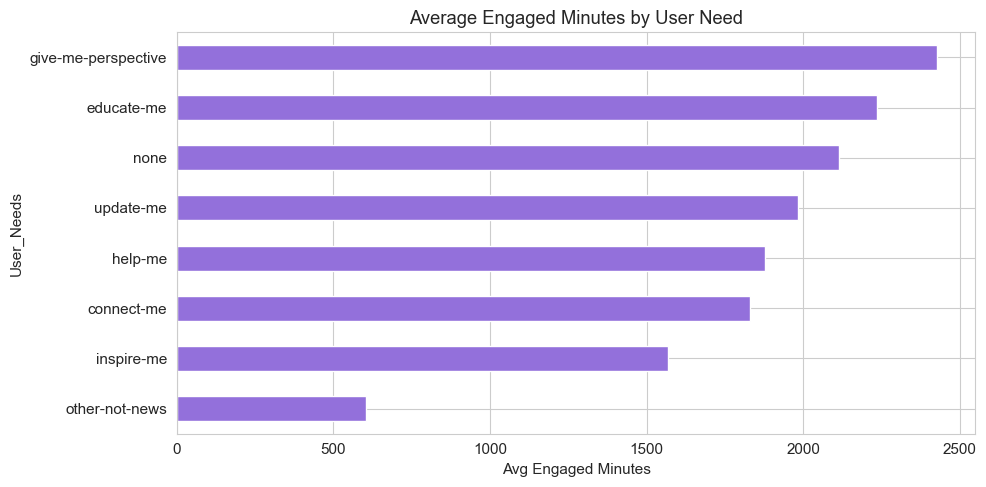

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

eng_by_need = eda_df.groupby('User_Needs')['Engaged minutes'].mean().sort_values(ascending=True)
eng_by_need.plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Average Engaged Minutes by User Need')
ax.set_xlabel('Avg Engaged Minutes')

plt.tight_layout()
plt.show()

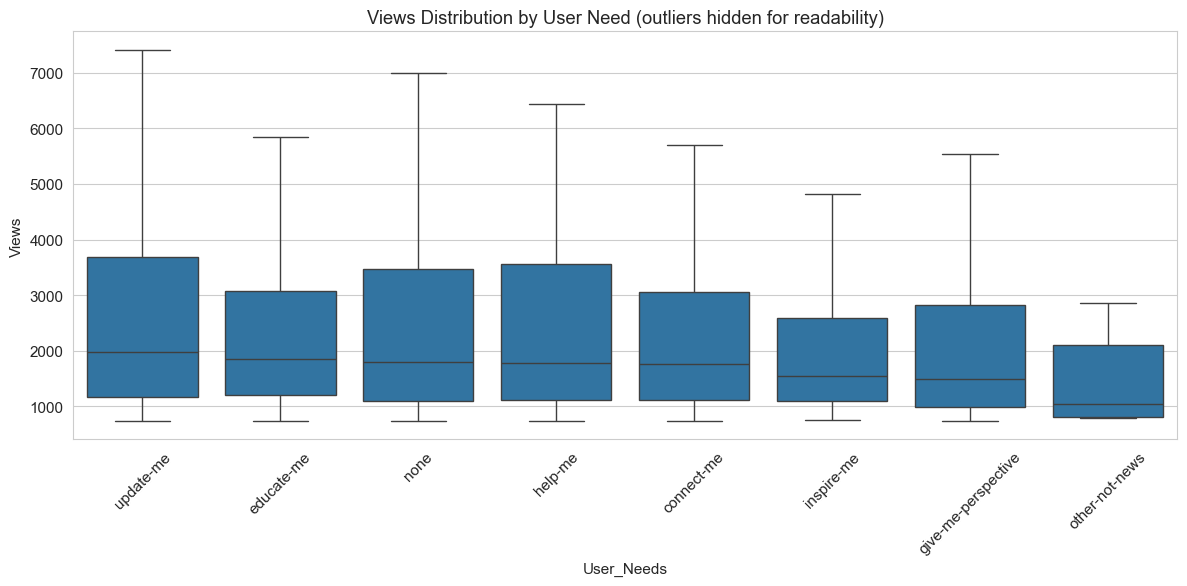

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

order = eda_df.groupby('User_Needs')['Views'].median().sort_values(ascending=False).index
sns.boxplot(data=eda_df, x='User_Needs', y='Views', order=order, ax=ax, showfliers=False)
ax.set_title('Views Distribution by User Need (outliers hidden for readability)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Device Breakdown


Device columns found: ['Desktop views', 'Mobile views', 'Tablet views']

Total views by device:
Desktop views     9869271.0
Mobile views     18790494.0
Tablet views       583245.0
dtype: float64



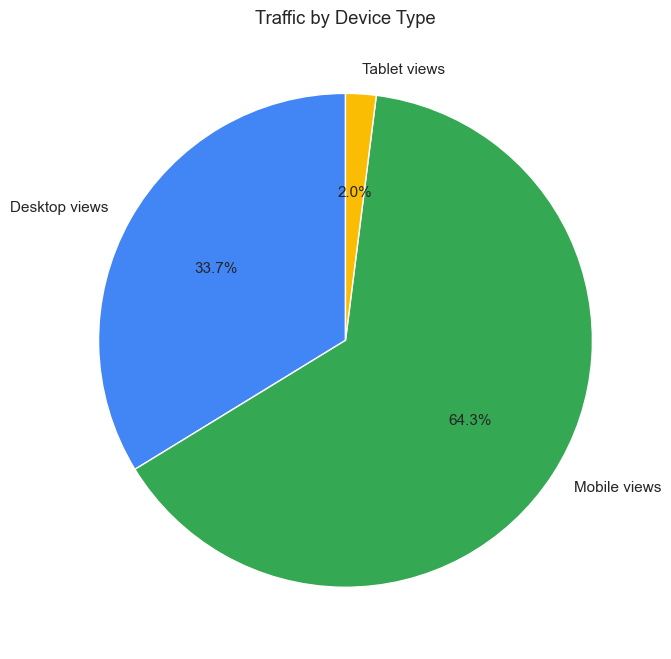

In [22]:
# overall device split
device_cols = [c for c in eda_df.columns if any(d in c.lower() for d in ['desktop', 'mobile', 'tablet'])]
print('Device columns found:', device_cols)
print()

if len(device_cols) >= 3:
    device_totals = eda_df[device_cols].sum()
    print('Total views by device:')
    print(device_totals)
    print()
    
    fig, ax = plt.subplots(figsize=(7, 7))
    device_totals.plot(kind='pie', ax=ax, autopct='%1.1f%%', 
                       colors=['#4285F4', '#34A853', '#FBBC04'],
                       startangle=90)
    ax.set_title('Traffic by Device Type')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

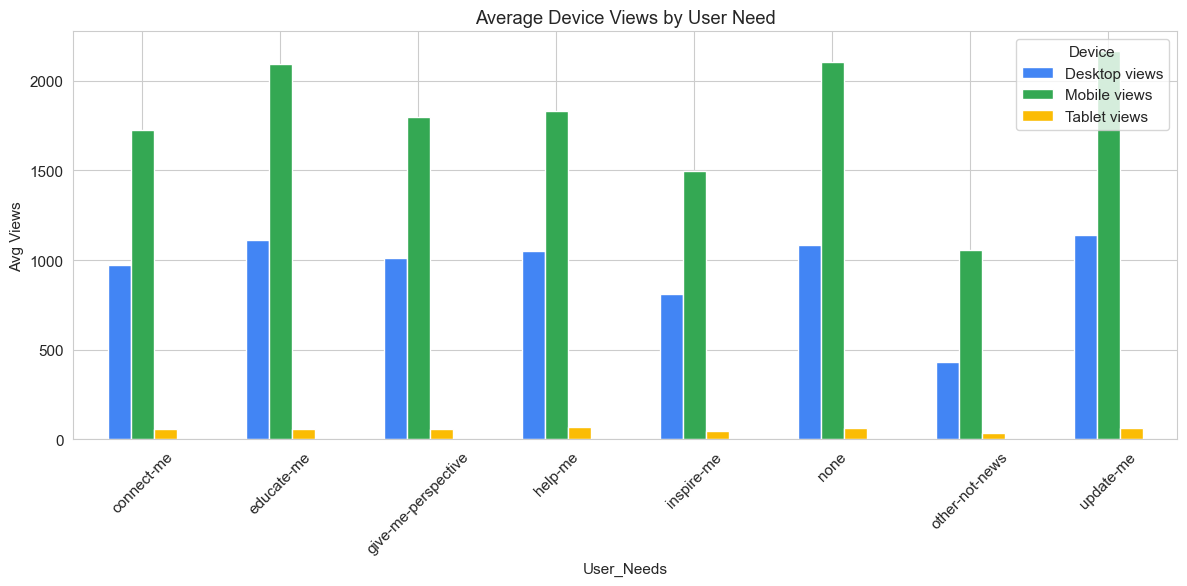

In [23]:
if len(device_cols) >= 3:
    device_by_need = eda_df.groupby('User_Needs')[device_cols].mean()
    
    device_by_need.plot(kind='bar', figsize=(12, 6), color=['#4285F4', '#34A853', '#FBBC04'])
    plt.title('Average Device Views by User Need')
    plt.ylabel('Avg Views')
    plt.xticks(rotation=45)
    plt.legend(title='Device')
    plt.tight_layout()
    plt.show()

## Section Analysis


In [24]:
# check if Section column exists in eda data
if 'Section' in eda_df.columns:
    print('Top 15 sections by article count:')
    print(eda_df['Section'].value_counts().head(15))
    print()
    
    sec_perf = eda_df.groupby('Section').agg(
        count=('Views', 'count'),
        avg_views=('Views', 'mean'),
        total_views=('Views', 'sum')
    ).sort_values('avg_views', ascending=False)
    
    print('Top 15 sections by average views:')
    print(sec_perf.head(15).round(2))
else:
    print('No Section column in EDA data')

Top 15 sections by article count:
Section
News                3509
Business            1132
Sports               974
Life & Culture       669
Opinion              503
Local & State        407
Maine                235
Letters              223
Politics             197
Kennebec Journal     164
Food                 126
Times Record         124
Do This               87
Football              80
Health                48
Name: count, dtype: int64

Top 15 sections by average views:
                       count  avg_views  total_views
Section                                             
Uncategorized              1    9919.00         9919
Feature Obituary           8    5649.00        45192
Lewiston-Auburn           14    5309.64        74335
Baseball                   1    4566.00         4566
Letters to the Editor     25    4539.84       113496
Politics                 197    4428.95       872504
National Sports            1    4152.00         4152
Maine Crime                4    3973.25      

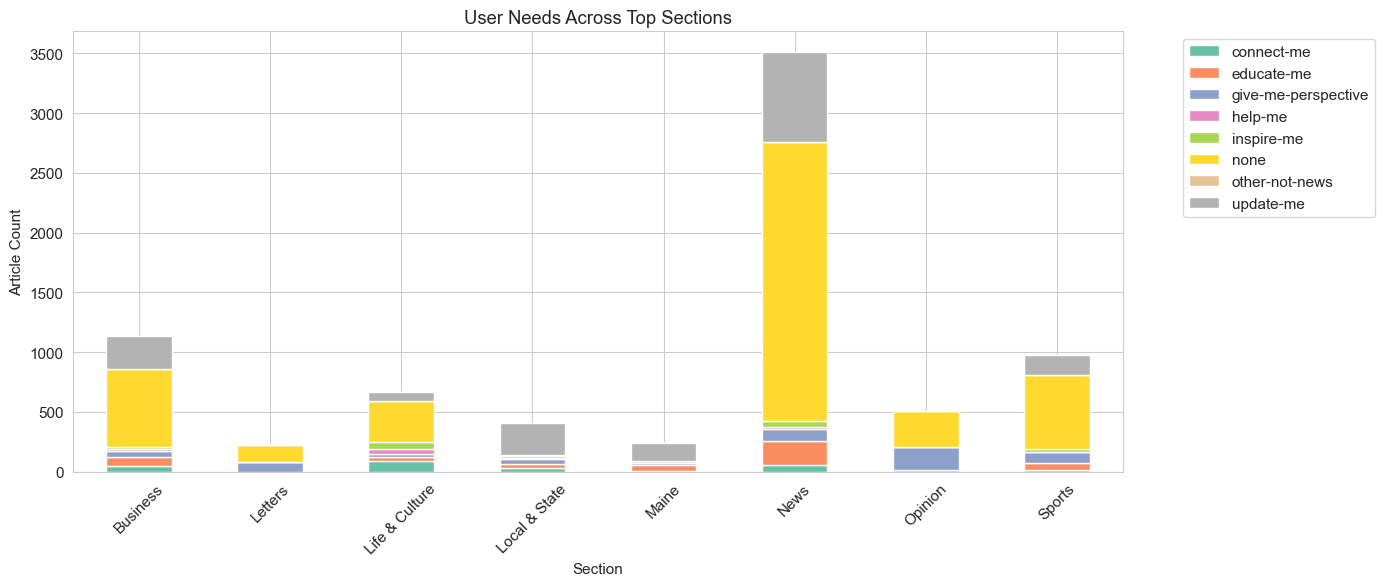

In [25]:
if 'Section' in eda_df.columns:
    top_sections = eda_df['Section'].value_counts().head(8).index
    subset = eda_df[eda_df['Section'].isin(top_sections)]
    
    ct = pd.crosstab(subset['Section'], subset['User_Needs'])
    ct.plot(kind='bar', stacked=True, figsize=(14, 6), 
            colormap='Set2')
    plt.title('User Needs Across Top Sections')
    plt.ylabel('Article Count')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Publication Breakdown


In [26]:
print('Posts export columns:')
print(posts_df.columns.tolist())
print()
print('Unique values in key categorical columns:')
for col in posts_df.select_dtypes(include='object').columns[:5]:
    print(f'{col}: {posts_df[col].nunique()} unique')

Posts export columns:
['Apikey', 'URL', 'Title', 'Publish date', 'Authors', 'Section', 'Tags', 'Sort (Views)', 'Visitors', 'Views', 'Avg. views', 'Engaged minutes', 'Avg. minutes', 'New vis.', 'Views new vis.', 'Avg. views new vis.', 'Minutes New Vis.', 'Avg. minutes new vis.', 'Returning vis.', 'Views ret. vis.', 'Avg. views ret. vis.', 'Minutes Ret. Vis.', 'Avg. minutes ret. vis.', 'Desktop views', 'Mobile views', 'Tablet views', 'Search refs', 'Internal refs', 'Other refs', 'Direct refs', 'Social refs', 'Fb refs', 'Tw refs', 'Pi refs', 'Social interactions', 'Fb interactions', 'Pi interactions', 'Channel vis.', 'Website views', 'AMP views', 'Fb instant views', 'Post id', 'Views source', 'Views syndicated', 'Views by Site', 'High-Level Smart Tags', 'Low-Level Smart Tags']

Unique values in key categorical columns:
Apikey: 7 unique
URL: 10000 unique
Title: 9363 unique
Publish date: 7662 unique
Authors: 998 unique


In [27]:
# try to find the publication/apikey column
pub_col = None
for c in posts_df.columns:
    if 'apikey' in c.lower() or 'pub' in c.lower() or 'site' in c.lower():
        pub_col = c
        break

if pub_col:
    print(f'Publication column: {pub_col}')
    print(posts_df[pub_col].value_counts())
else:
    # might just be the first column
    print('First column values:')
    print(posts_df.iloc[:, 0].value_counts())

Publication column: Apikey
Apikey
centralmaine.com, pressherald.com, sunjournal.com    3695
pressherald.com                                      3572
sunjournal.com                                       1028
centralmaine.com                                      955
pressherald.com, sunjournal.com                       318
centralmaine.com, pressherald.com                     275
centralmaine.com, sunjournal.com                      157
Name: count, dtype: int64


## 12. Tagged vs Untagged 

Tagged articles: 3928 (43.1%)
Untagged articles: 5189 (56.9%)
Total: 9117



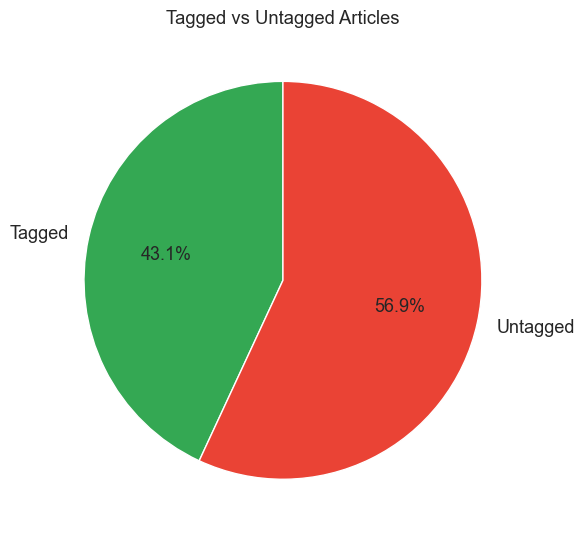

In [28]:
n_tagged = len(tagged_df)
n_untagged = len(untagged_df)
total = n_tagged + n_untagged

print(f'Tagged articles: {n_tagged} ({round(n_tagged/total*100, 1)}%)')
print(f'Untagged articles: {n_untagged} ({round(n_untagged/total*100, 1)}%)')
print(f'Total: {total}')
print()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([n_tagged, n_untagged], labels=['Tagged', 'Untagged'],
       autopct='%1.1f%%', colors=['#34A853', '#EA4335'],
       startangle=90, textprops={'fontsize': 13})
ax.set_title('Tagged vs Untagged Articles')
plt.tight_layout()
plt.show()

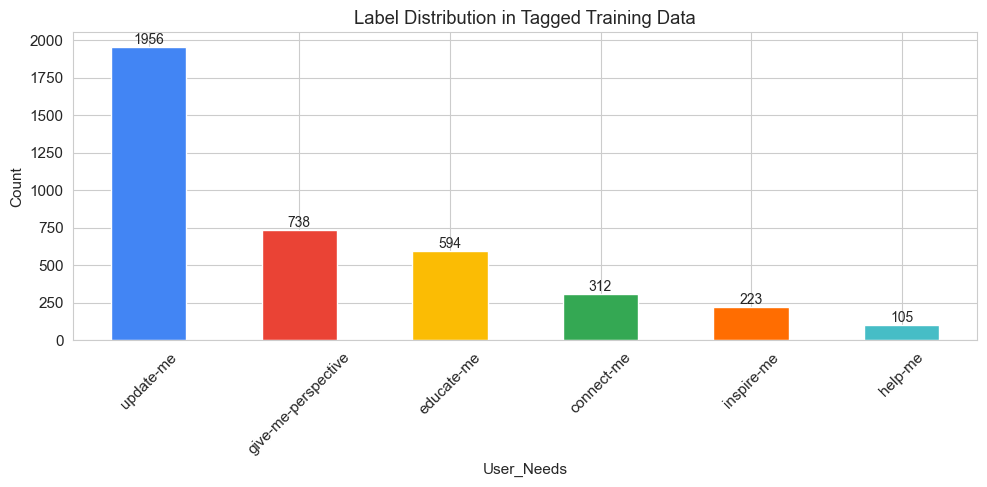

Class balance ratios (relative to largest class):
User_Needs
update-me              1.000
give-me-perspective    0.377
educate-me             0.304
connect-me             0.160
inspire-me             0.114
help-me                0.054
Name: count, dtype: float64


In [29]:
# class balance in the tagged set — this is what our supervised model trains on
tag_dist = tagged_df['User_Needs'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
tag_dist.plot(kind='bar', ax=ax, color=colors[:len(tag_dist)])
ax.set_title('Label Distribution in Tagged Training Data')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(tag_dist.values):
    ax.text(i, v + max(tag_dist)*0.01, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Class balance ratios (relative to largest class):')
print(round(tag_dist / tag_dist.max(), 3))

## Title Length Analysis


Title length stats:
                     title_length  word_count
User_Needs                                   
connect-me                   63.0        10.2
educate-me                   67.0        10.9
give-me-perspective          66.0        11.1
help-me                      64.1        11.1
inspire-me                   64.8        10.6
update-me                    65.0        10.0



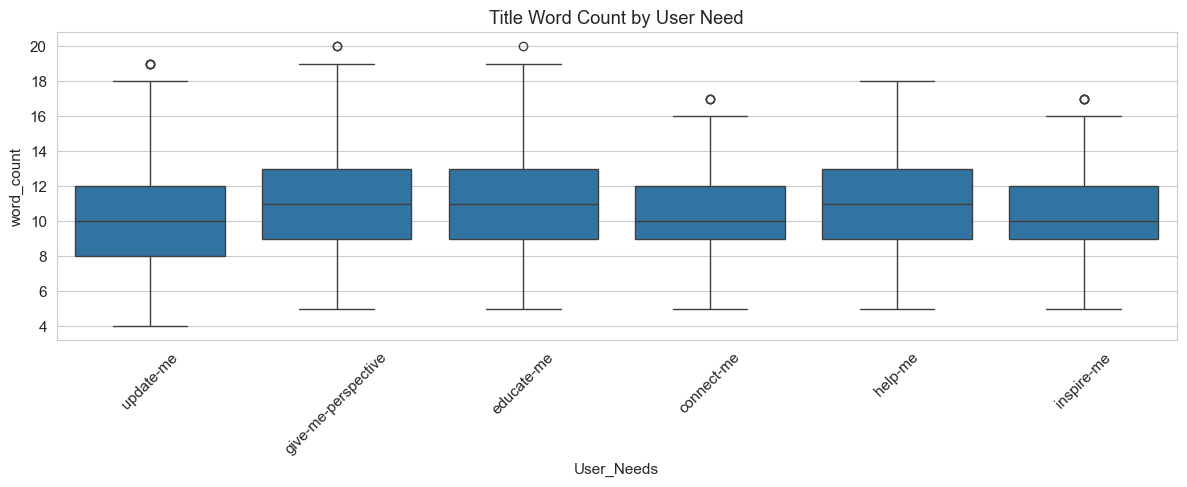

In [30]:
tagged_df['title_length'] = tagged_df['Title'].astype(str).apply(len)
tagged_df['word_count'] = tagged_df['Title'].astype(str).apply(lambda x: len(x.split()))

print('Title length stats:')
print(tagged_df.groupby('User_Needs')[['title_length', 'word_count']].mean().round(1))
print()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=tagged_df, x='User_Needs', y='word_count', ax=ax)
ax.set_title('Title Word Count by User Need')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Correlation Matrix


Numeric columns (7): ['Views', 'Avg. views', 'Engaged minutes', 'Avg. minutes', 'Desktop views', 'Mobile views', 'Tablet views']



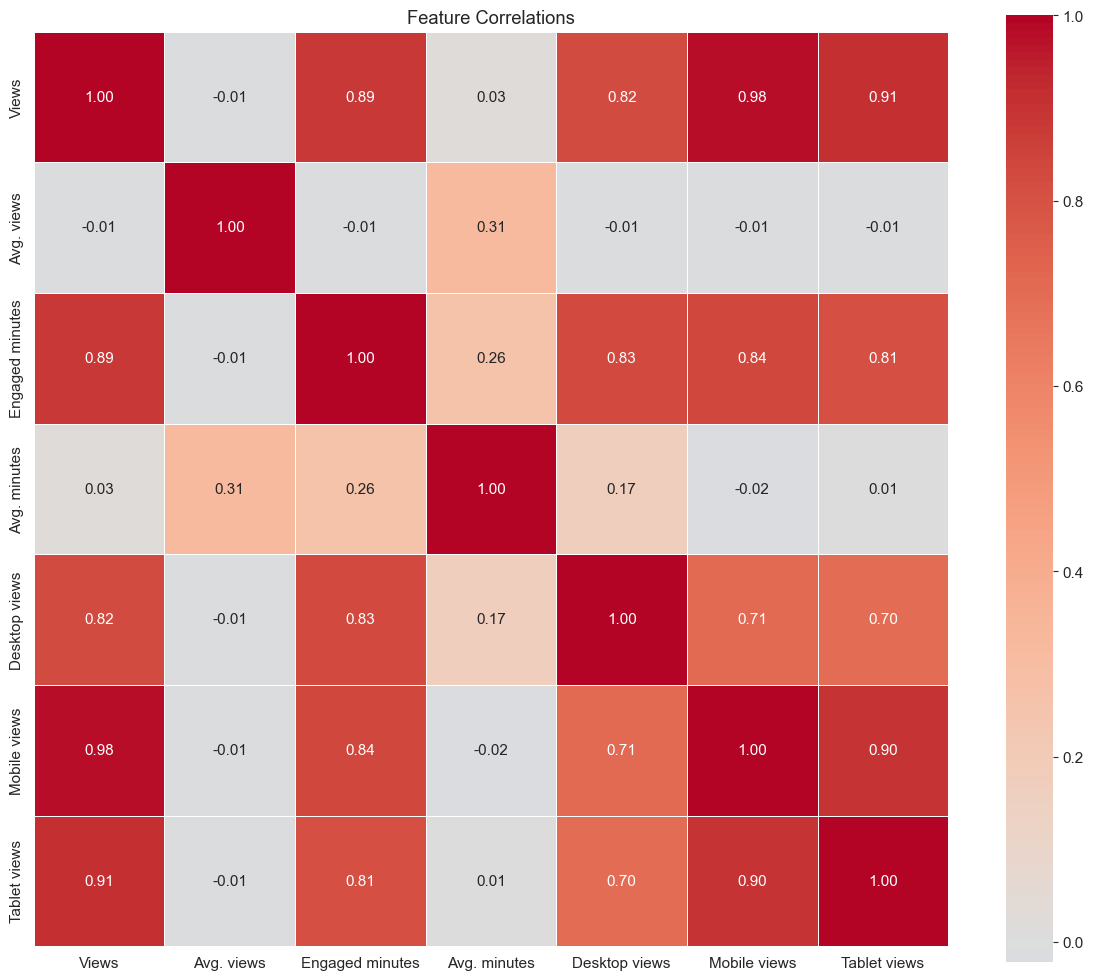

In [31]:
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print()

if len(numeric_cols) > 2:
    corr = eda_df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, square=True, linewidths=0.5)
    ax.set_title('Feature Correlations')
    plt.tight_layout()
    plt.show()

##  Top Performing Articles


In [32]:
top_articles = eda_df.nlargest(20, 'Views')[['Title', 'User_Needs', 'Section', 'Views', 'Engaged minutes']]
top_articles = top_articles.reset_index(drop=True)
top_articles.index = top_articles.index + 1
print('Top 20 Articles by Views:')
top_articles

Top 20 Articles by Views:


,Title,User_Needs,Section,Views,Engaged minutes
1,Gray investigated for buying $1.25M fire truck...,update-me,News,109875,31960.0
2,Social Security now requires Maine parents to ...,none,News,98329,64495.0
3,"ICE agents shatter window, leave 1-month-old b...",give-me-perspective,News,76168,84939.0
4,Maine Mall shooting: Police search for suspect...,none,News,73901,38065.0
5,Bob Dylan and Willie Nelson headline Outlaw Mu...,none,Life & Culture,64763,23763.0
6,Graham Platner says he will remove a Nazi-link...,educate-me,Politics,62651,29502.0
7,Maine housing advocates warn of coming ‘tsunam...,none,News,55705,30152.0
8,Follow live: Maine statewide and town-by-town ...,none,Politics,54192,23511.0
9,"Suspect in deadly Windham shooting ‘located,’ ...",none,News,50560,42044.0
10,Trump administration cancels USM college progr...,update-me,News,48740,17989.0


In [33]:
print('User needs among top 50 articles:')
top50 = eda_df.nlargest(50, 'Views')
print(top50['User_Needs'].value_counts())

User needs among top 50 articles:
User_Needs
none                   32
update-me              10
give-me-perspective     4
educate-me              4
Name: count, dtype: int64


## Summary Stats Table



In [34]:
summary = eda_df.groupby('User_Needs').agg(
    articles=('Views', 'count'),
    total_views=('Views', 'sum'),
    mean_views=('Views', 'mean'),
    median_views=('Views', 'median'),
    std_views=('Views', 'std'),
    avg_engagement=('Engaged minutes', 'mean'),
    avg_minutes=('Avg. minutes', 'mean') if 'Avg. minutes' in eda_df.columns else ('Engaged minutes', 'mean')
).round(2)

summary['pct_of_articles'] = round(summary['articles'] / summary['articles'].sum() * 100, 1)
summary['pct_of_views'] = round(summary['total_views'] / summary['total_views'].sum() * 100, 1)

print('=== User Needs Performance Summary ===')
summary

=== User Needs Performance Summary ===


,articles,total_views,mean_views,median_views,std_views,avg_engagement,avg_minutes,pct_of_articles,pct_of_views
User_Needs,,,,,,,,,
connect-me,312,860248,2757.21,1756.0,2963.16,1829.90,0.75,3.4,2.9
educate-me,594,1938732,3263.86,1856.5,4912.52,2237.65,0.81,6.5,6.6
give-me-perspective,738,2117505,2869.25,1486.0,4740.80,2428.98,0.99,8.1,7.2
help-me,105,309789,2950.37,1782.0,3001.34,1878.41,0.73,1.2,1.1
inspire-me,223,526338,2360.26,1549.0,2366.87,1569.03,0.79,2.4,1.8
none,5184,16886930,3257.51,1800.5,4779.93,2115.51,0.80,56.9,57.7
other-not-news,5,7607,1521.40,1052.0,916.25,605.20,0.44,0.1,0.0
update-me,1956,6595865,3372.12,1982.5,4780.09,1984.10,0.68,21.5,22.6
